In [2]:
import os
import pandas as pd

# Define dataset directory
base_dir = r"D:\brain project\Dataset"
modalities = ["CT", "MRI"]
categories = ["Haemorrhagic", "Ischemic", "Normal", "Stroke"]

# List to store data
data = []

# Iterate through CT and MRI directories
for modality in modalities:
    modality_path = os.path.join(base_dir, modality)
    
    for category in categories:
        category_path = os.path.join(modality_path, category)
        
        if os.path.exists(category_path):  # Ensure category exists
            for image in os.listdir(category_path):
                if image.lower().endswith(('.jpg', '.png', '.jpeg')):  # Check for image files
                    image_path = os.path.join(category_path, image)
                    data.append([image_path, modality, category])

# Convert to DataFrame
df = pd.DataFrame(data, columns=["Image_Path", "Modality", "Category"])

# Save as CSV file
csv_path = os.path.join(base_dir, "brain_stroke_dataset.csv")
df.to_csv(csv_path, index=False)

print(f"CSV file created successfully at: {csv_path}")


CSV file created successfully at: D:\brain project\Dataset\brain_stroke_dataset.csv


In [1]:
import pandas as pd

# Load the CSV file
csv_path = r"D:\brain project\Dataset\brain_stroke_dataset.csv"
df = pd.read_csv(csv_path)

# Count the number of CT and MRI scans
modality_counts = df["Modality"].value_counts()

# Count per category
category_counts = df.groupby("Modality")["Category"].value_counts()

# Print results
print("Total counts for each modality:")
print(modality_counts)
print("\nCategory-wise counts:")
print(category_counts)


Total counts for each modality:
Modality
CT     5812
MRI     611
Name: count, dtype: int64

Category-wise counts:
Modality  Category    
CT        Normal          2201
          Stroke          1545
          Ischemic        1063
          Haemorrhagic    1003
MRI       Normal           399
          Haemorrhagic     185
          Ischemic          27
Name: count, dtype: int64


C:\Users\madha\AppData\Local\Temp\ipykernel_13916\2315009521.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modality_counts.index, y=modality_counts.values, palette="coolwarm")


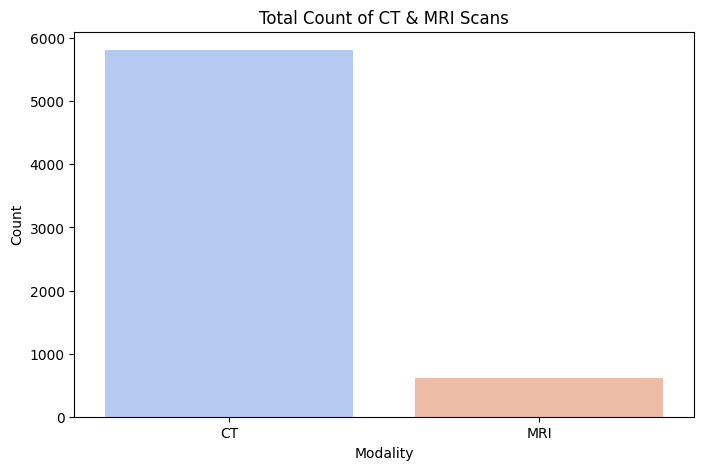

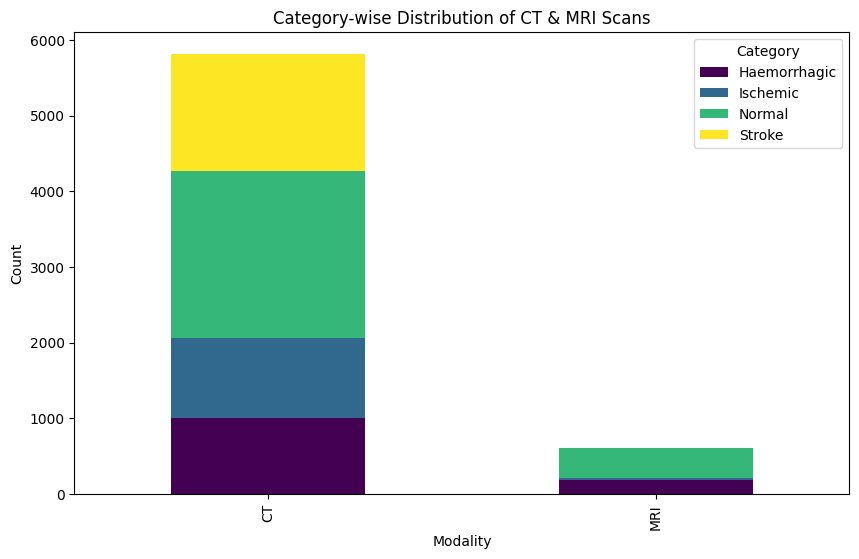

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
csv_path = r"D:\brain project\Dataset\brain_stroke_dataset.csv"
df = pd.read_csv(csv_path)

# Count total CT & MRI scans
modality_counts = df["Modality"].value_counts()

# Count per category
category_counts = df.groupby("Modality")["Category"].value_counts().unstack()

# Plot Modality Count
plt.figure(figsize=(8, 5))
sns.barplot(x=modality_counts.index, y=modality_counts.values, palette="coolwarm")
plt.title("Total Count of CT & MRI Scans")
plt.xlabel("Modality")
plt.ylabel("Count")
plt.show()

# Plot Category-wise Distribution
category_counts.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Category-wise Distribution of CT & MRI Scans")
plt.xlabel("Modality")
plt.ylabel("Count")
plt.legend(title="Category")
plt.show()


In [10]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Load dataset CSV
csv_path = r"D:\brain project\Dataset\brain_stroke_dataset.csv"
df = pd.read_csv(csv_path)

# Define Image Transformations (Resize, Normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize
])

# Custom Dataset Class
class BrainStrokeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.label_map = {"Haemorrhagic": 0, "Ischemic": 1, "Normal": 2, "Stroke": 3}  # Assign numeric labels

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = self.label_map[self.dataframe.iloc[idx]["Category"]]

        # Open Image
        image = Image.open(img_path).convert("RGB")

        # Apply Transformations
        if self.transform:
            image = self.transform(image)

        return image, label

# Create Dataset
dataset = BrainStrokeDataset(df, transform=transform)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test DataLoader
sample_batch = next(iter(dataloader))
print("Batch Image Shape:", sample_batch[0].shape)  # Should be (32, 3, 224, 224)
print("Batch Labels:", sample_batch[1])  # Example labels


Batch Image Shape: torch.Size([32, 3, 224, 224])
Batch Labels: tensor([1, 3, 3, 1, 1, 3, 0, 3, 1, 3, 1, 0, 3, 3, 0, 2, 3, 1, 2, 3, 0, 3, 1, 1,
        3, 3, 0, 1, 0, 0, 3, 0])


In [16]:
import torchvision.models as models

model = models.resnet18(pretrained=True)


In [17]:
from torchvision.models import ResNet18_Weights
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import accuracy_score
from tqdm import tqdm  # Import tqdm for the progress bar

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Enable fast training if GPU is available
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # Speeds up training

# Load Pretrained ResNet-18
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)  # 4 output classes (Haemorrhagic, Ischemic, Normal, Stroke)
model = model.to(device)

# Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Parameters
num_epochs = 10  # Adjust as needed
best_acc = 0.0  # Track the best accuracy
save_path = "brain_stroke_model_best.pth"

# Training Loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Use tqdm to show progress bar for each epoch
    with tqdm(dataloader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch') as pbar:
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Update progress bar with loss info
            pbar.set_postfix(loss=running_loss / (total // 32), accuracy=(correct / total) * 100)

    # Calculate loss & accuracy for the entire epoch
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = (correct / total) * 100

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

    # Save the best model
    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), save_path)
        print(f"✅ Best model saved with Accuracy: {best_acc:.2f}%")

print("Training complete. Best model saved as:", save_path)


Using device: cpu


Epoch 1/10: 100%|██████████| 201/201 [08:27<00:00,  2.53s/batch, accuracy=44.4, loss=1.13]


Epoch [1/10], Loss: 1.1229, Accuracy: 44.40%
✅ Best model saved with Accuracy: 44.40%


Epoch 2/10: 100%|██████████| 201/201 [08:12<00:00,  2.45s/batch, accuracy=53, loss=0.967]  


Epoch [2/10], Loss: 0.9626, Accuracy: 53.00%
✅ Best model saved with Accuracy: 53.00%


...

Epoch [8/10], Loss: 0.6607, Accuracy: 66.32%
✅ Best model saved with Accuracy: 66.32%


Epoch 9/10: 100%|██████████| 201/201 [12:03<00:00,  3.60s/batch, accuracy=68.5, loss=0.611]


Epoch [9/10], Loss: 0.6083, Accuracy: 68.53%
✅ Best model saved with Accuracy: 68.53%


Epoch 10/10: 100%|██████████| 201/201 [11:43<00:00,  3.50s/batch, accuracy=69.4, loss=0.584]

Epoch [10/10], Loss: 0.5809, Accuracy: 69.38%
✅ Best model saved with Accuracy: 69.38%
Training complete. Best model saved as: brain_stroke_model_best.pth


In [18]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd

# ✅ **Load the saved model**
model_path = r"D:\brain project\brain_stroke_model_best.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet-18 architecture
model = models.resnet18()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)  # 4 classes
model.load_state_dict(torch.load(model_path, map_location=device))  # Load trained weights
model = model.to(device)
model.eval()  # Set model to evaluation mode

print("✅ Model loaded successfully!")

# ✅ **Define Data Transformations**
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ✅ **Load Test Dataset**
class BrainStrokeTestDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.dataframe = pd.read_csv(csv_file)
        self.transform = transform
        self.label_map = {"Haemorrhagic": 0, "Ischemic": 1, "Normal": 2, "Stroke": 3}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = self.label_map[self.dataframe.iloc[idx]["Category"]]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# Path to test dataset CSV
test_csv_path = r"D:\brain project\Dataset\brain_stroke_dataset.csv"

# Load test dataset
test_dataset = BrainStrokeTestDataset(test_csv_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ✅ **Evaluate Model Accuracy**
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = (correct / total) * 100
print(f"📊 Model Accuracy on Test Data: {accuracy:.2f}%")


✅ Model loaded successfully!
📊 Model Accuracy on Test Data: 50.10%


✅ Model loaded successfully!


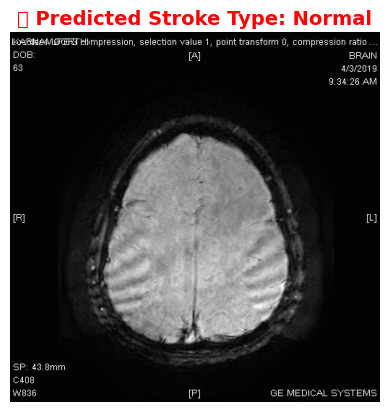

📌 Predicted Stroke Type: **Normal**


In [20]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# ✅ Load Model
model_path = r"D:\brain project\brain_stroke_model_best.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)  # 4 classes: Haemorrhagic, Ischemic, Normal, Stroke
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("✅ Model loaded successfully!")

# ✅ Define Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ✅ Manually Enter Image Path
image_path = input("🔹 Enter the image path: ")  # Manually input any image path

# ✅ Load and Preprocess Image
try:
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # ✅ Make Prediction
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted_class = torch.max(output, 1)

    # ✅ Class Mapping
    class_labels = {0: "Haemorrhagic", 1: "Ischemic", 2: "Normal", 3: "Stroke"}
    predicted_label = class_labels[predicted_class.item()]

    # ✅ Display Image with Prediction
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"📌 Predicted Stroke Type: {predicted_label}", fontsize=14, fontweight="bold", color="red")
    plt.show()

    # ✅ Print Output
    print(f"📌 Predicted Stroke Type: **{predicted_label}**")

except FileNotFoundError:
    print("❌ Error: The file path is incorrect or the image does not exist.")
except Exception as e:
    print(f"❌ Unexpected Error: {e}")


In [28]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ✅ Load dataset
file_path = r"D:\brain project\Dataset\filtered_stroke_data.csv"
df = pd.read_csv(file_path)

# ✅ Handle missing or 'Unknown' values in smoking_status
df['smoking_status'] = df['smoking_status'].replace('Unknown', df['smoking_status'].mode()[0])

# ✅ Encode categorical columns (Convert to numbers)
label_encoders = {}

for col in ['gender', 'ever_married', 'smoking_status']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save the encoders for reference

# ✅ Save the processed dataset
output_file = r"D:\brain project\Dataset\numeric_stroke_data.csv"
df.to_csv(output_file, index=False)

print(f"✅ Dataset successfully converted to numeric format and saved as '{output_file}'")
print(df.head())  # Display first few rows to verify


✅ Dataset successfully converted to numeric format and saved as 'D:\brain project\Dataset\numeric_stroke_data.csv'
   gender   age  hypertension  heart_disease  ever_married  avg_glucose_level  \
0       0  21.0             0              0             0              90.16   
1       0  52.0             1              0             1             233.29   
2       1  55.0             0              0             1              73.57   
3       0  51.0             0              0             1             105.63   
4       0  79.0             0              0             1             110.85   

    bmi  smoking_status  stroke  
0  28.9               2       0  
1  48.9               1       1  
2  28.0               2       0  
3  32.8               1       0  
4  24.1               0       1  


In [32]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# ✅ Load the numeric dataset
file_path = r"D:\brain project\Dataset\numeric_stroke_data.csv"
df = pd.read_csv(file_path)

# ✅ Define features and target variable
X = df.drop(columns=['stroke'])  # Features
y = df['stroke']  # Target (0 = No Stroke, 1 = Stroke)

# ✅ Normalize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ✅ Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# ✅ Create DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ✅ Define the Neural Network Model
class StrokePredictionModel(nn.Module):
    def __init__(self, input_dim):
        super(StrokePredictionModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 2)  # Output for 2 classes (Stroke / No Stroke)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# ✅ Training Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StrokePredictionModel(input_dim=X_train.shape[1]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# ✅ Training Loop
num_epochs = 50
best_accuracy = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_accuracy = (correct / total) * 100
    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        torch.save(model.state_dict(), r"D:\brain project\stroke_prediction_model.pth")
        print(f"✅ Best model saved with Accuracy: {best_accuracy:.2f}%")

print(f"🏆 Training complete. Best model saved with Accuracy: {best_accuracy:.2f}%")

# ✅ Model Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy = (correct / total) * 100
print(f"📊 Model Accuracy on Test Data: {accuracy:.2f}%")


Epoch [1/50], Loss: 0.6808, Accuracy: 54.28%
✅ Best model saved with Accuracy: 54.28%
Epoch [2/50], Loss: 0.5900, Accuracy: 75.25%
✅ Best model saved with Accuracy: 75.25%
Epoch [3/50], Loss: 0.5059, Accuracy: 76.84%
✅ Best model saved with Accuracy: 76.84%
Epoch [4/50], Loss: 0.4831, Accuracy: 77.50%
✅ Best model saved with Accuracy: 77.50%
Epoch [5/50], Loss: 0.4765, Accuracy: 77.37%
Epoch [6/50], Loss: 0.4750, Accuracy: 77.41%
Epoch [7/50], Loss: 0.4748, Accuracy: 77.68%
✅ Best model saved with Accuracy: 77.68%
Epoch [8/50], Loss: 0.4670, Accuracy: 77.86%
✅ Best model saved with Accuracy: 77.86%
Epoch [9/50], Loss: 0.4648, Accuracy: 77.93%
✅ Best model saved with Accuracy: 77.93%
Epoch [10/50], Loss: 0.4635, Accuracy: 78.10%
✅ Best model saved with Accuracy: 78.10%
Epoch [11/50], Loss: 0.4627, Accuracy: 78.29%
✅ Best model saved with Accuracy: 78.29%
Epoch [12/50], Loss: 0.4630, Accuracy: 78.23%
Epoch [13/50], Loss: 0.4580, Accuracy: 78.26%
Epoch [14/50], Loss: 0.4563, Accuracy: 78.

📊 Final Model Accuracy on Test Data: 81.49%


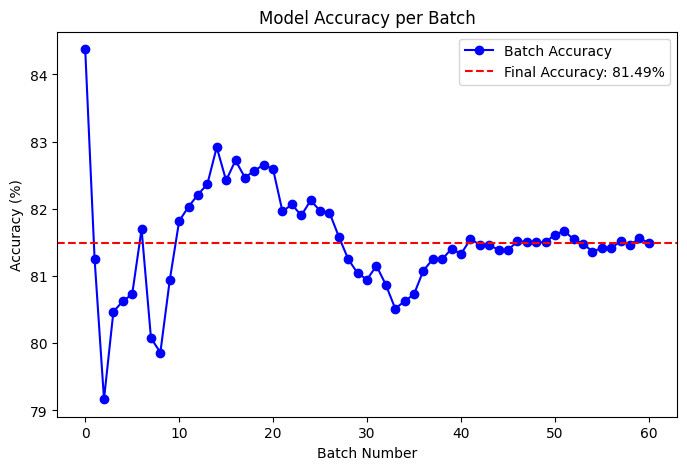

In [42]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ✅ Load the numeric dataset
file_path = r"D:\brain project\Dataset\numeric_stroke_data.csv"
df = pd.read_csv(file_path)

# ✅ Define features and target variable
X = df.drop(columns=['stroke'])  # Features
y = df['stroke']  # Target (0 = No Stroke, 1 = Stroke)

# ✅ Normalize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ✅ Convert to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# ✅ Create DataLoader for testing
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ✅ Define the same model structure
class StrokePredictionModel(nn.Module):
    def __init__(self, input_dim):
        super(StrokePredictionModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 2)  # Output for 2 classes (Stroke / No Stroke)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# ✅ Load the saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StrokePredictionModel(input_dim=X_train.shape[1]).to(device)
model.load_state_dict(torch.load(r"D:\brain project\stroke_prediction_model.pth"))
model.eval()

# ✅ Evaluate Model Accuracy on Test Data
correct = 0
total = 0
accuracies = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        accuracies.append((correct / total) * 100)  # Store accuracy per batch

# ✅ Compute overall accuracy
final_accuracy = (correct / total) * 100
print(f"📊 Final Model Accuracy on Test Data: {final_accuracy:.2f}%")

# ✅ Plot Accuracy per Batch
plt.figure(figsize=(8, 5))
plt.plot(accuracies, marker='o', linestyle='-', color='blue', label='Batch Accuracy')
plt.axhline(y=final_accuracy, color='red', linestyle='--', label=f'Final Accuracy: {final_accuracy:.2f}%')
plt.xlabel("Batch Number")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy per Batch")
plt.legend()
plt.show()


In [53]:
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ✅ Define the same model structure (should match training)
class StrokePredictionModel(torch.nn.Module):
    def __init__(self, input_dim):
        super(StrokePredictionModel, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, 64)
        self.fc2 = torch.nn.Linear(64, 32)
        self.fc3 = torch.nn.Linear(32, 16)
        self.fc4 = torch.nn.Linear(16, 2)  # Output for 2 classes (Stroke / No Stroke)
        self.relu = torch.nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# ✅ Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StrokePredictionModel(input_dim=8).to(device)
model.load_state_dict(torch.load(r"D:\brain project\stroke_prediction_model.pth"))
model.eval()

# ✅ Load and fit the scaler on the full numeric dataset
df_train = pd.read_csv(r"D:\brain project\Dataset\numeric_stroke_data.csv")
scaler = StandardScaler()
scaler.fit(df_train.drop(columns=['stroke']))  # Fit on training features

# ✅ Function to predict stroke (YES/NO)
def predict_stroke(input_data):
    """
    Takes a new patient’s data and predicts Stroke (YES/NO).
    """
    columns = ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'bmi', 'smoking_status']
    df = pd.DataFrame([input_data], columns=columns)

    # ✅ Normalize input features
    df_scaled = scaler.transform(df)  # Transform using pre-fitted scaler

    # Convert to PyTorch tensor
    input_tensor = torch.tensor(df_scaled, dtype=torch.float32).to(device)

    # ✅ Perform prediction
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted_class = torch.max(output, 1)  # Get class (0 or 1)

    return "🛑 **Stroke: YES** ⚠️" if predicted_class.item() == 1 else "✅ **Stroke: NO**"

# ✅ Example Test Cases from Your Dataset
test_patient_1 = [0,52.0,1,0,1,233.29,48.9,1]  # Should be YES
test_patient_2 = [0,79.0,0,0,1,110.85,24.1,0]   # Should be NO
test_patient_3 = [1,67.0,0,1,1,228.69,36.6,0]  # Should be YES
test_patient_4 = [0,63.0,0,0,1,197.54,28.1,1]   # Should be NO

# ✅ Run predictions
print("Test 1:", predict_stroke(test_patient_1))  
print("Test 2:", predict_stroke(test_patient_2))  
print("Test 3:", predict_stroke(test_patient_3))  
print("Test 4:", predict_stroke(test_patient_4))  


Test 1: 🛑 **Stroke: YES** ⚠️
Test 2: 🛑 **Stroke: YES** ⚠️
Test 3: 🛑 **Stroke: YES** ⚠️
Test 4: 🛑 **Stroke: YES** ⚠️
